# Edge Detection: Comparison of Sobel and Canny Filters
Edge detection is a fundamental step in image processing, helping to identify object boundaries. This notebook explores and compares two widely used edge detection techniques: the Sobel and Canny filters.
The goal of this comparison is to analyze their effectiveness and characteristics in detecting edges under different conditions.

In [47]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## 1. Sobel Edge Detection
### 1.1 Manual Implementation
The Sobel filter detects edges by computing intensity gradients in both the horizontal (x) and vertical (y) directions. Here, a manual implementation is used, where the Sobel kernels are applied using convolution to extract gradient information. The magnitude of the gradients is then computed to obtain the edge map.

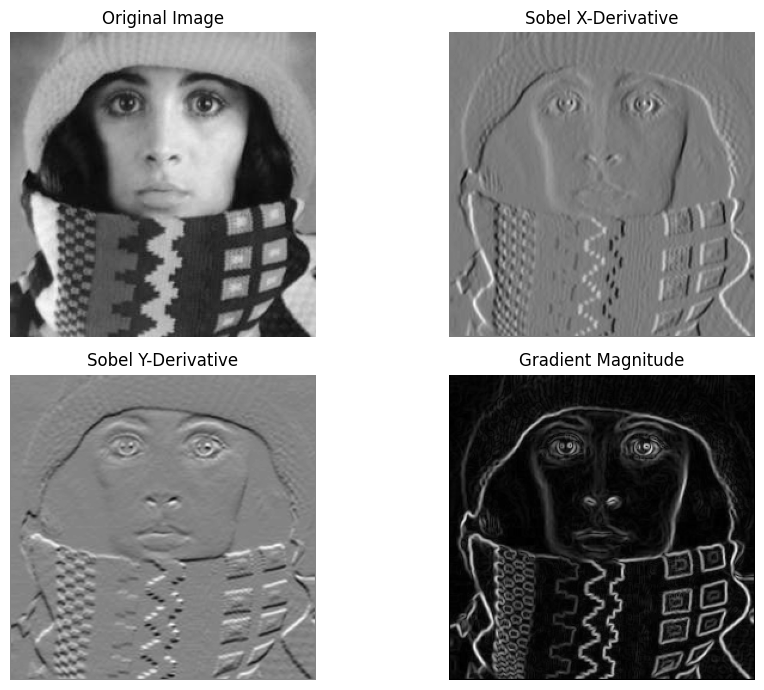

In [10]:
# Load the grayscale image
img = cv2.imread("trui.png", cv2.IMREAD_GRAYSCALE)

# Define the Sobel kernels
Gx = np.array([[-1, 0, 1],
               [-2, 0, 2], 
               [-1, 0, 1]])

Gy = np.array([[-1, -2, -1], 
               [0, 0, 0],
               [1, 2, 1]])

# Initialize output images
img_x = np.zeros_like(img, dtype=np.float32)
img_y = np.zeros_like(img, dtype=np.float32)

# Apply the Sobel filter using nested loops
for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
        img_x[i, j] = np.sum(Gx * img[i-1:i+2, j-1:j+2])
        img_y[i, j] = np.sum(Gy * img[i-1:i+2, j-1:j+2])

# Compute gradient magnitude
magnitude = np.sqrt(img_x**2 + img_y**2)

# Normalize for visualization
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Display results
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_x, cmap="gray")
axes[0, 1].set_title('Sobel X-Derivative')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_y, cmap="gray")
axes[1, 0].set_title('Sobel Y-Derivative')
axes[1, 0].axis('off')

axes[1, 1].imshow(magnitude, cmap="gray")
axes[1, 1].set_title('Gradient Magnitude')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### 1.2 OpenCV Implementation
Instead of manually applying the Sobel kernels, OpenCV’s built-in Sobel function is used to compute the x and y derivatives, followed by the gradient magnitude to extract edges.

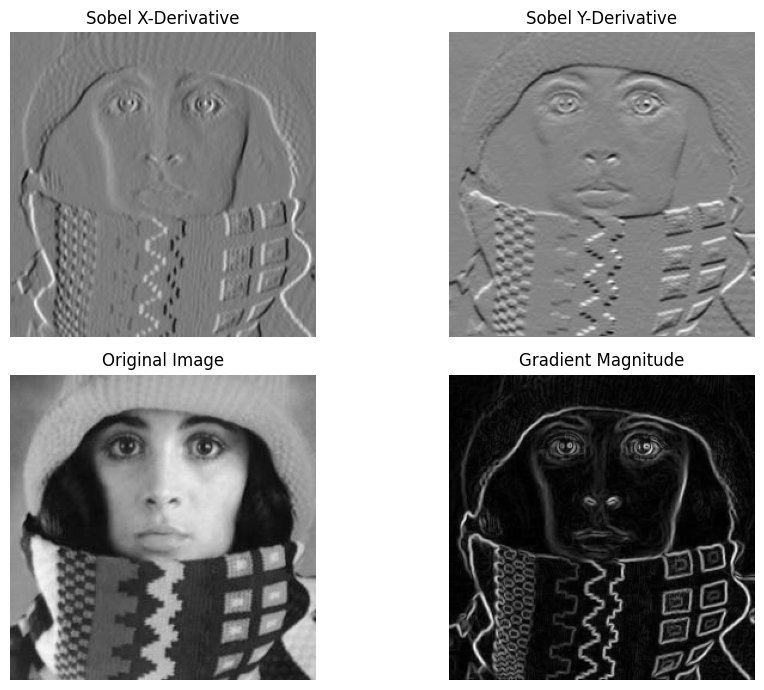

In [23]:
# Compute Sobel derivatives using OpenCV
edgesx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
edgesy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Compute gradient magnitude
sobel_edges = np.sqrt(np.square(edgesx) + np.square(edgesy))
sobel_edges = cv2.normalize(sobel_edges, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Display results
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].imshow(edgesx, cmap="gray")
axes[0, 0].set_title('Sobel X-Derivative')
axes[0, 0].axis('off')

axes[0, 1].imshow(edgesy, cmap="gray")
axes[0, 1].set_title('Sobel Y-Derivative')
axes[0, 1].axis('off')

axes[1, 0].imshow(img, cmap="gray")
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_edges, cmap="gray")
axes[1, 1].set_title('Gradient Magnitude')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Canny Edge Detection
The Canny filter is applied to the image, following a multi-stage process that includes Gaussian smoothing, gradient computation, non-maximum suppression, and hysteresis thresholding. This method effectively detects edges while reducing noise interference.

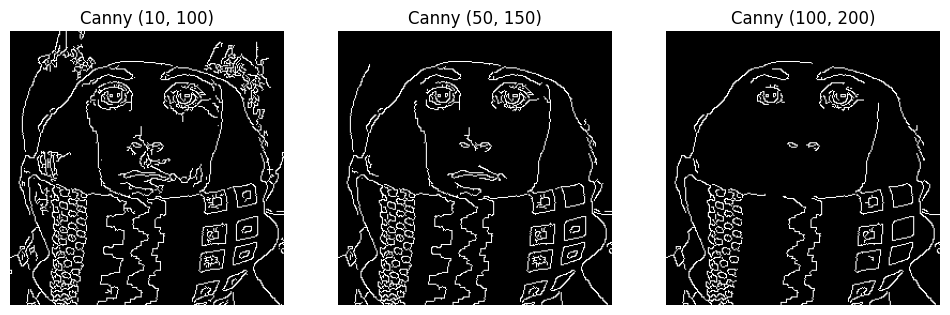

In [46]:
# Apply Canny edge detection with different threshold values
# The first parameter is the lower threshold, and the second parameter is the upper threshold.
# Any edge with a gradient intensity above the upper threshold is considered a strong edge.
# Any edge with a gradient intensity below the lower threshold is discarded as noise.
# Edges with intensities between the two thresholds are only considered if they are connected to strong edges.

canny_low = cv2.Canny(img, 10, 100)   # Low thresholds: detects more edges, including weak and noisy ones
canny_mid = cv2.Canny(img, 50, 150)   # Moderate thresholds: balanced detection of strong and weak edges
canny_high = cv2.Canny(img, 100, 200) # High thresholds: detects only the most prominent edges, reducing noise

# Display the results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

ax1.imshow(canny_low, cmap="gray")
ax1.set_title("Canny (10, 100)")
ax1.axis('off')

ax2.imshow(canny_mid, cmap="gray")
ax2.set_title("Canny (50, 150)")
ax2.axis('off')

ax3.imshow(canny_high, cmap="gray")
ax3.set_title("Canny (100, 200)")
ax3.axis('off')

plt.show()

The choice of threshold values significantly affects the results of the Canny edge detector. The optimal threshold range depends on the image characteristics, such as contrast and noise level.

In general, lower thresholds make the detector more sensitive, while higher thresholds improve edge selectivity.

## Comparison of Sobel and Canny Edge Detection

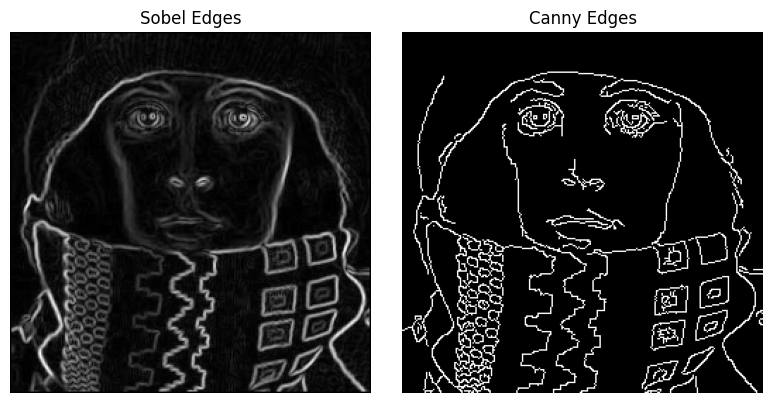

In [38]:
# Apply Canny edge detection
canny_edges = cv2.Canny(img, 50, 150)

# Display Sobel vs. Canny edge detection
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(magnitude, cmap="gray")
axes[0].set_title('Sobel Edges')
axes[0].axis('off')

axes[1].imshow(canny_edges, cmap="gray")
axes[1].set_title('Canny Edges')
axes[1].axis('off')

plt.tight_layout()
plt.show()

- The **Canny filter** employs a multi-stage approach, beginning with Gaussian smoothing to reduce noise. It then computes gradient magnitude and direction using the Sobel operator, applies non-maximum suppression to thin out edges, and finally uses hysteresis thresholding to distinguish strong and weak edges.

- In contrast, the **Sobel filter** directly computes gradients but does not incorporate additional processing steps, resulting in thicker edges that may not precisely delineate object boundaries. The Canny filter enhances edge detection by removing weak features, yielding thinner and more well-defined edges.